# Text Wrangling and Regex
Working with text: applying string methods and regular expressions

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import zipfile
import pandas as pd

import warnings
warnings.filterwarnings("ignore")



## 🥫 Demo 1: Canonicalizing County Names

In [5]:
states = pd.read_csv("county_and_state.csv")
populations = pd.read_csv("county_and_population.csv")

# display() allows us to view a DataFrame without returning it as an object
display(states)
display(populations)


,County,State
0,De Witt County,IL
1,Lac qui Parle County,MN
2,Lewis and Clark County,MT
3,St John the Baptist Parish,LS


,County,Population
0,DeWitt,16798
1,Lac Qui Parle,8067
2,Lewis & Clark,55716
3,St. John the Baptist,43044


Both of these DataFrames share a "County" column. Unfortunately, formatting differences mean that we can't directly merge the two DataFrames using the "County"s.

In [6]:
states.merge(populations, left_on="County", right_on="County")


,County,State,Population


## 🐼 Using Pandas String Functions

To address this, we can **canonicalize** the "County" string data to apply a common formatting.

In [9]:
# Function to transform a series of county names into a standard form
def canonicalize_county(county_series):
    canonicalized_series = (
        county_series
        # make lowercase
        .str.lower()   
        # remove spaces            
        .str.replace(' ', '')    
        # replace & with and               
        .str.replace('&', 'and')   
         # remove dots             
        .str.replace('.', '')       
        # remove "county"           
        .str.replace('county', '')
        # remove "parish" 
        .str.replace('parish', '')              
    )
    return (canonicalized_series)

display(canonicalize_county(states["County"]))
display(canonicalize_county(populations["County"]))


0              dewitt
1         lacquiparle
2       lewisandclark
3    stjohnthebaptist
Name: County, dtype: object

0              dewitt
1         lacquiparle
2       lewisandclark
3    stjohnthebaptist
Name: County, dtype: object

In [10]:
states["Canonical County"] = canonicalize_county(states["County"])

populations["Canonical County"] = canonicalize_county(populations["County"])

display(states)
display(populations)


,County,State,Canonical County
0,De Witt County,IL,dewitt
1,Lac qui Parle County,MN,lacquiparle
2,Lewis and Clark County,MT,lewisandclark
3,St John the Baptist Parish,LS,stjohnthebaptist


,County,Population,Canonical County
0,DeWitt,16798,dewitt
1,Lac Qui Parle,8067,lacquiparle
2,Lewis & Clark,55716,lewisandclark
3,St. John the Baptist,43044,stjohnthebaptist


Now, the merge works as expected!

In [11]:
states.merge(populations, on="Canonical County")


,County_x,State,Canonical County,County_y,Population
0,De Witt County,IL,dewitt,DeWitt,16798
1,Lac qui Parle County,MN,lacquiparle,Lac Qui Parle,8067
2,Lewis and Clark County,MT,lewisandclark,Lewis & Clark,55716
3,St John the Baptist Parish,LS,stjohnthebaptist,St. John the Baptist,43044


## ♻️Demo 2: Extracting Data from Log Files

In [13]:
# Sample log file
log_fname = 'log.txt'

with open(log_fname, 'r') as f:
    # readlines() returns a list of strings, 
    # with each element representing a line in the file
    log_lines = f.readlines()
    
log_lines


['169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n',
 '193.205.203.3 - - [2/Feb/2005:17:23:6 -0800] "GET /stat141/Notes/dim.html HTTP/1.0" 404 302 "http://eeyore.ucdavis.edu/stat141/Notes/session.html"\n',
 '169.237.46.240 - "" [3/Feb/2006:10:18:37 -0800] "GET /stat141/homework/Solutions/hw1Sol.pdf HTTP/1.1"']

Suppose we want to extract the day, month, year, hour, minutes, seconds, and timezone.

- Looking at the data, we see that these items are not in a fixed position relative to the beginning of the string.

- In other words, slicing by some fixed offset isn't going to work.

In [14]:
# 20:31 were determined by trial-and-error!
log_lines[0][20:31] 


'26/Jan/2014'

What happens if we use the same range for the next log line?

In [15]:
log_lines[1][20:31]


'/Feb/2005:1'

Instead, we'll need to use some more sophisticated thinking. Let's focus on only the first line of the file.

In [16]:
first = log_lines[0]
first


'169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n'

Find the data inside the square brackes by splitting the string at [ and ].

In [17]:
# find the text enclosed in square brackets
pertinent = (

    # remove everything before the first [
    first.split("[")[1] 

    # Remove everything after the second square ]
    .split(']')[0] 

) 

pertinent


'26/Jan/2014:10:47:58 -0800'

In [18]:
# grab the date, month, and the rest of the pertinent string (`rest`)
day, month, rest  = pertinent.split('/')        

print("Day:   ", day)
print("Month: ", month)
print("Rest:  ", rest)


Day:    26
Month:  Jan
Rest:   2014:10:47:58 -0800


In [19]:
# from `rest`, grab the year, hour, minute, and remaining characters
year, hour, minute, rest2 = rest.split(':')    

print("Year:   ", year)
print("Hour:   ", hour)
print("Minute: ", minute)
print("Rest:   ", rest2)


Year:    2014
Hour:    10
Minute:  47
Rest:    58 -0800


In [20]:
# from `rest2`, grab the seconds and time zone
seconds, time_zone = rest2.split(' ') 
print("Seconds:   ", seconds)
print("Time Zone:   ", time_zone)


Seconds:    58
Time Zone:    -0800


In [21]:
# Print all the components we've extracted
day, month, year, hour, minute, seconds, time_zone


('26', 'Jan', '2014', '10', '47', '58', '-0800')

Repeating the process above, but simultaenously for all lines of the log file:

In [22]:
logs = pd.read_csv("log.txt", 
                sep="\t", 
                header=None)[0]

print("Original input:")
display(logs)


Original input:


0    169.237.46.168 - - [26/Jan/2014:10:47:58 -0800...
1    193.205.203.3 - - [2/Feb/2005:17:23:6 -0800] "...
2    169.237.46.240 - "" [3/Feb/2006:10:18:37 -0800...
Name: 0, dtype: object

In [23]:
# Previous code:
# first = '26/Jan/2014:10:47:58 -0800'
# pertinent = first.split("[")[1].split(']')[0]

s1 = (
  logs.str.split("[")
      .str[1]
      .str.split("]")
      .str[0]
)
display(s1)


0    26/Jan/2014:10:47:58 -0800
1      2/Feb/2005:17:23:6 -0800
2     3/Feb/2006:10:18:37 -0800
Name: 0, dtype: object

In [24]:
# Previous code:
# day, month, rest  = pertinent.split('/') 

df1 = (
  # expand=True creates a column for each element of the split
  s1.str.split("/", expand=True)
  .rename(columns={0: "Day", 1: "Month", 2: "Rest"})
)
df1


,Day,Month,Rest
0,26,Jan,2014:10:47:58 -0800
1,2,Feb,2005:17:23:6 -0800
2,3,Feb,2006:10:18:37 -0800


In [25]:
# Previous code:
# year, hour, minute, rest2 = rest.split(':') 

rest_df = (
  df1["Rest"].str.split(":", expand=True)
  .rename(columns={0: "Year", 1: "Hour", 2: "Minute", 3: "Rest2"})
)
display(rest_df)


,Year,Hour,Minute,Rest2
0,2014,10,47,58 -0800
1,2005,17,23,6 -0800
2,2006,10,18,37 -0800


In [26]:
df2 = (
  # merge based on the index, not a particular column
  df1.merge(rest_df, left_index=True, right_index=True)
  .drop(columns=["Rest"])
)
df2


,Day,Month,Year,Hour,Minute,Rest2
0,26,Jan,2014,10,47,58 -0800
1,2,Feb,2005,17,23,6 -0800
2,3,Feb,2006,10,18,37 -0800


In [27]:
# Previous code:
# seconds, time_zone = rest.split(' ')

rest2_df = (
  df2["Rest2"].str.split(" ", expand=True)
  .rename(columns = {0: "Seconds", 1: "Timezone"})
)
rest2_df


,Seconds,Timezone
0,58,-0800
1,6,-0800
2,37,-0800


In [28]:
df3 = (
    df2.merge(rest2_df, left_index=True, right_index=True)
    .drop(columns=["Rest2"])
)

print("Final Dataframe:")
display(df3)


Final Dataframe:


,Day,Month,Year,Hour,Minute,Seconds,Timezone
0,26,Jan,2014,10,47,58,-0800
1,2,Feb,2005,17,23,6,-0800
2,3,Feb,2006,10,18,37,-0800


You may see code like this in data cleaning pipelines.

However, regular expressions provide a faster and more expressive mechanism to extract strings that match certain patterns.

## 💬 Regular Expressions

www.regex101.com is a great place to experiment with regular expressions!

Quadruple blackslash example from slides:

In [29]:
# prints newline
print('One backslash:')
print('\n')

# prints \n
print('Two backslashes:')
print('\\n')

# prints \ followed by newline
print('Three backslashes:')
print('\\\n')

# prints \\n
print('Four backslashes:')
print('\\\\n')

# also prints \\n, but much more obviously!
print('Raw string:')
print(r'\\n')


One backslash:


Two backslashes:
\n
Three backslashes:
\

Four backslashes:
\\n
Raw string:
\\n


Lesson: Use raw strings to simplify regular expressions in Python!

## 🎻 String Extraction with Regex

Python *re.findall* returns a list of all extracted matches from a single string:

In [30]:
import re

text = "My social security number is 123-45-6789 bro, or actually maybe it’s 321-45-6789.";

pattern = r"[0-9]{3}-[0-9]{2}-[0-9]{4}"

re.findall(pattern, text)


['123-45-6789', '321-45-6789']

Now, let's see vectorized extraction in pandas:

*.str.findall* returns a Series of lists of all matches in each record.

In other words, it effectively applies *re.findall* to each element of the Series

In [31]:
df_ssn = pd.DataFrame(
    ['987-65-4321',
     'forty',
     '123-45-6789 bro or 321-45-6789',
     '999-99-9999'],
    columns=['SSN'])
df_ssn


,SSN
0,987-65-4321
1,forty
2,123-45-6789 bro or 321-45-6789
3,999-99-9999


In [32]:
# Series of lists
pattern = r"[0-9]{3}-[0-9]{2}-[0-9]{4}"
df_ssn['SSN'].str.findall(pattern)


0                 [987-65-4321]
1                            []
2    [123-45-6789, 321-45-6789]
3                 [999-99-9999]
Name: SSN, dtype: object

In [33]:
# For example, grab the final match from each list
(
  df_ssn['SSN']
  .str.findall(pattern)
  .str[-1] 
)


0    987-65-4321
1            NaN
2    321-45-6789
3    999-99-9999
Name: SSN, dtype: object

In [34]:
text = """I will meet you at 08:30:00 pm tomorrow"""       
pattern = ".*(\d\d):(\d\d):(\d\d).*"
matches = re.findall(pattern, text)
matches


[('08', '30', '00')]

In [35]:
# The three capture groups in the first matched string
hour, minute, second = matches[0]
print("Hour:   ", hour)
print("Minute: ", minute)
print("Second: ", second)


Hour:    08
Minute:  30
Second:  00


In [36]:
# back to SSNs
df_ssn


,SSN
0,987-65-4321
1,forty
2,123-45-6789 bro or 321-45-6789
3,999-99-9999


In [37]:
# Will extract the first match of all groups
pattern_group_mult = r"([0-9]{3})-([0-9]{2})-([0-9]{4})" # 3 groups
df_ssn['SSN'].str.extract(pattern_group_mult)


,0,1,2
0,987,65,4321
1,NaN,NaN,NaN
2,123,45,6789
3,999,99,9999


In [38]:
# DataFrame, one row per match
df_ssn['SSN'].str.extractall(pattern_group_mult)


0   1     2
  match               
0 0      987  65  4321
2 0      123  45  6789
  1      321  45  6789
3 0      999  99  9999

## 🧲 Extraction Using Regex Capture Groups

The Python function *re.findall*, in combination with parentheses returns specific substrings (i.e., **capture groups**) within each matched string, or match.

In [39]:
text = """I will meet you at 08:30:00 pm tomorrow"""       
pattern = ".*(\d\d):(\d\d):(\d\d).*"
matches = re.findall(pattern, text)
matches

[('08', '30', '00')]

In [40]:
# The three capture groups in the first matched string
hour, minute, second = matches[0]
print("Hour:   ", hour)
print("Minute: ", minute)
print("Second: ", second)

Hour:    08
Minute:  30
Second:  00


In pandas, we can use *.str.extract* to extract each capture group of only the first match of each record into separate columns.

In [41]:
# back to SSNs
df_ssn

,SSN
0,987-65-4321
1,forty
2,123-45-6789 bro or 321-45-6789
3,999-99-9999


In [42]:
# Will extract the first match of all groups
pattern_group_mult = r"([0-9]{3})-([0-9]{2})-([0-9]{4})" # 3 groups
df_ssn['SSN'].str.extract(pattern_group_mult)

,0,1,2
0,987,65,4321
1,NaN,NaN,NaN
2,123,45,6789
3,999,99,9999


Alternatively, *.str.extractall* extracts all matches of each record into separate columns. Rows are then **MultiIndexed** by original record index and match index.

In [43]:
# DataFrame, one row per match
df_ssn['SSN'].str.extractall(pattern_group_mult)

0   1     2
  match               
0 0      987  65  4321
2 0      123  45  6789
  1      321  45  6789
3 0      999  99  9999

## 🥫 Canonicalization with Regex (re.sub, Series.str.replace)

In regular Python, canonicalize with re.sub ("substitute"):

In [44]:
text = '<div><td valign="top">Moo</td></div>'
pattern = r"<[^>]+>"
re.sub(pattern, '', text)


'Moo'

In pandas, canonicalize with *Series.str.replace*.

In [45]:
# example dataframe of strings
df_html = pd.DataFrame(
  [
    '<div><td valign="top">Moo</td></div>',
    '<a href="http://ds100.org">Link</a>',
    '<b>Bold text</b>'
  ], 
  columns=['Html'])

df_html


,Html
0,"<div><td valign=""top"">Moo</td></div>"
1,"<a href=""http://ds100.org"">Link</a>"
2,<b>Bold text</b>


In [46]:
# Series -> Series
df_html["Html"].str.replace(pattern, '', regex=True).to_frame()


,Html
0,Moo
1,Link
2,Bold text


## 🍽️ Real World Case Study: Restaurant Data

In this example, we will show how regexes can allow us to track quantitative data across categories defined by the appearance of various text fields.

In this example we'll exploare how the presence of certain keywords can affect quantitative data:

- How do restaurant health scores vary as a function of the number of violations that mention a particular keyword? (e.g., unclean surfaces, vermin, permits, etc.)

In [68]:
vio = pd.read_csv('violations.csv', header=0, names=['points', 'bid', 'desc'])
desc = vio['desc']
vio.head()


,points,bid,desc
0,1,DAJ5UNMSF,"# 44. Floors, walls and ceilings: properly bui..."
1,4,DAT2HKIRE,# 07. Proper hot and cold holding temperatures
2,1,DAT2HKIRE,# 33. Nonfood-contact surfaces clean and in go...
3,1,DAT2HKIRE,# 35. Equipment/Utensils - approved; installed...
4,1,DAQN0I8EA,# 33. Nonfood-contact surfaces clean and in go...


In [69]:
counts = desc.value_counts()
counts.shape


(112,)

In [70]:
counts[:10]


# 44. Floors, walls and ceilings: properly built, maintained in good repair and clean    102012
# 33. Nonfood-contact surfaces clean and in good repair                                  100083
# 35. Equipment/Utensils - approved; installed; clean; good repair, capacity              80020
# 40. Plumbing: Plumbing in good repair, proper backflow devices                          50870
# 36. Equipment, utensils and linens: storage and use                                     49744
# 37. Adequate ventilation and lighting; designated areas, use                            48046
# 43. Premises; personal/cleaning items; vermin-proofing                                  42949
# 07. Proper hot and cold holding temperatures                                            41110
# 30. Food properly stored; food storage containers identified                            39855
# 39. Wiping cloths: properly used and stored                                             35849
Name: desc, dtype: int64

In [71]:
# Hmmm...
counts[50:60]


Cockroaches                                                                     42
# 49. Samples Collected                                                         40
# 02. Communicable disease; reporting, restrictions & exclusions                40
# 03. No discharge from eyes, nose, and mouth                                   37
Permit Suspension                                                               35
Walls, Floors, Ceilings: approved, maintained clean and in good repair          32
Equipment, Shelving, Cabinets: approved, maintained clean and in good repair    31
# 12. Returned and reservice food                                               31
Floor maintained clean                                                          23
Hot and cold water available                                                    18
Name: desc, dtype: int64

If there is a lot of different descriptions, we can canonicalize by using regular expression to clean them.

In [72]:
# Use regular expressions to cut out the extra info in square braces.
vio['clean_desc'] = (vio['desc']
             .str.replace(r'\s*\[.*\]$', '', regex=True)
             .str.strip()       # removes leading/trailing whitespace
             .str.lower())
vio.head()


,points,bid,desc,clean_desc
0,1,DAJ5UNMSF,"# 44. Floors, walls and ceilings: properly bui...","# 44. floors, walls and ceilings: properly bui..."
1,4,DAT2HKIRE,# 07. Proper hot and cold holding temperatures,# 07. proper hot and cold holding temperatures
2,1,DAT2HKIRE,# 33. Nonfood-contact surfaces clean and in go...,# 33. nonfood-contact surfaces clean and in go...
3,1,DAT2HKIRE,# 35. Equipment/Utensils - approved; installed...,# 35. equipment/utensils - approved; installed...
4,1,DAQN0I8EA,# 33. Nonfood-contact surfaces clean and in go...,# 33. nonfood-contact surfaces clean and in go...


In [73]:
# canonicalizing definitely helped
vio['clean_desc'].value_counts().shape


(112,)

In [74]:
vio['clean_desc'].value_counts().head() 


# 44. floors, walls and ceilings: properly built, maintained in good repair and clean    102012
# 33. nonfood-contact surfaces clean and in good repair                                  100083
# 35. equipment/utensils - approved; installed; clean; good repair, capacity              80020
# 40. plumbing: plumbing in good repair, proper backflow devices                          50870
# 36. equipment, utensils and linens: storage and use                                     49744
Name: clean_desc, dtype: int64

Remember our research question:

- How do restaurant health scores vary as a function of the number of violations that mention a particular keyword? (e.g., unclean surfaces, vermin, permits, etc.)

Below, we use regular expressions and *df.assign()* to method chain our creation of new boolean features, one per keyword.

In [75]:
# use regular expressions to assign new features for the presence of various keywords
# regex metacharacter | 
with_features = (vio
 .assign(is_unclean     = vio['clean_desc'].str.contains('clean|sanit'))
 .assign(is_high_risk = vio['clean_desc'].str.contains('high risk'))
 .assign(is_vermin    = vio['clean_desc'].str.contains('vermin'))
 .assign(is_surface   = vio['clean_desc'].str.contains('wall|ceiling|floor|surface'))
 .assign(is_human     = vio['clean_desc'].str.contains('hand|glove|hair|nail'))
 .assign(is_permit    = vio['clean_desc'].str.contains('permit|certif'))
)
with_features.head()


,points,bid,desc,clean_desc,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
0,1,DAJ5UNMSF,"# 44. Floors, walls and ceilings: properly bui...","# 44. floors, walls and ceilings: properly bui...",True,False,False,True,False,False
1,4,DAT2HKIRE,# 07. Proper hot and cold holding temperatures,# 07. proper hot and cold holding temperatures,False,False,False,False,False,False
2,1,DAT2HKIRE,# 33. Nonfood-contact surfaces clean and in go...,# 33. nonfood-contact surfaces clean and in go...,True,False,False,True,False,False
3,1,DAT2HKIRE,# 35. Equipment/Utensils - approved; installed...,# 35. equipment/utensils - approved; installed...,True,False,False,False,False,False
4,1,DAQN0I8EA,# 33. Nonfood-contact surfaces clean and in go...,# 33. nonfood-contact surfaces clean and in go...,True,False,False,True,False,False


## 📊 EDA
That's the end of our text wrangling. Now let's do some more analysis to analyze restaurant health as a function of the number of violation keywords.

To do so we'll first group so that our **granularity** is one inspection for a business on particular date. This effectively counts the number of violations by keyword for a given inspection.

In [77]:
count_features = (with_features
 .groupby(['bid', 'points'])
 .sum(numeric_only=True)
 .reset_index()
)
count_features.iloc[255:260, :]


,bid,points,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
255,DA00HBS0U,2,1,0,0,1,0,0
256,DA00HF5Z2,4,0,0,0,0,0,0
257,DA00HHS40,1,2,0,0,2,0,0
258,DA00HNRSL,1,2,0,1,1,0,0
259,DA00HNRSL,2,0,0,0,0,1,1


Check out our new dataframe in action:

In [78]:
count_features[count_features['is_vermin'] > 1].head(5)


,bid,points,is_unclean,is_high_risk,is_vermin,is_surface,is_human,is_permit
9850,DA0JOOEF0,1,2,0,2,0,0,2
16134,DA0W3VQQQ,1,3,0,2,0,0,0
61485,DA90RJALU,1,2,0,2,0,0,0
184473,DAKXUZOWQ,1,3,0,2,0,0,0
249015,DAQXTULRT,1,3,0,2,0,0,0


Now we'll reshape this "wide" table into a "tidy" table using a pandas feature called *pd.melt* which we won't describe in any detail, other than that it's effectively the inverse of pd.pivot_table.

Our granularity is now a violation type for a given inspection (for a business on a particular date).

In [80]:
violation_type_df = pd.melt(count_features, id_vars=['bid', 'points'],
            var_name='feature', value_name='num_vios')

# show a particular inspection's results
violation_type_df[(violation_type_df['bid'] == "DA0JOOEF0") & (violation_type_df['points'] == 1)]


,bid,points,feature,num_vios
9850,DA0JOOEF0,1,is_unclean,2
356527,DA0JOOEF0,1,is_high_risk,0
703204,DA0JOOEF0,1,is_vermin,2
1049881,DA0JOOEF0,1,is_surface,0
1396558,DA0JOOEF0,1,is_human,0
1743235,DA0JOOEF0,1,is_permit,2


Remember our research question:

- How do restaurant health scores vary as a function of the number of violations that mention a particular keyword? (e.g., unclean surfaces, vermin, permits, etc.)



We have the second half of this question! Now let's join our table with the inspection scores, located in *inspections.csv*.

In [81]:
# read in the scores
inspection_df = pd.read_csv('inspections.csv',
                  header=0,
                  usecols=[0, 1, 2],
                  names=['data','score', 'bid'])
inspection_df.head()


,data,score,bid
0,5/9/2017,98,DAHDRUQZO
1,4/10/2017,94,DAL3SBUE0
2,4/4/2017,95,DAL2PIKJU
3,8/15/2017,98,DA0ZMAJXZ
4,9/26/2016,96,DA41DBXA2


While the inspection scores were stored in a separate file from the violation descriptions, we notice that the primary key in inspections is (bid)! So we can reference this key in our join.

In [83]:
# join scores with the table broken down by violation type
violation_type_and_scores = (
    violation_type_df
    .merge(inspection_df, on=['bid'])
)
violation_type_and_scores.head(12)


,bid,points,feature,num_vios,data,score
0,DA0007NP7,1,is_unclean,1,8/16/2017,98
1,DA0007NP7,1,is_high_risk,0,8/16/2017,98
2,DA0007NP7,1,is_vermin,0,8/16/2017,98
3,DA0007NP7,1,is_surface,1,8/16/2017,98
4,DA0007NP7,1,is_human,0,8/16/2017,98
5,DA0007NP7,1,is_permit,0,8/16/2017,98
6,DA000ADVG,1,is_unclean,1,10/27/2017,98
7,DA000ADVG,1,is_high_risk,0,10/27/2017,98
8,DA000ADVG,1,is_vermin,0,10/27/2017,98
9,DA000ADVG,1,is_surface,0,10/27/2017,98


Let's plot the distribution of scores, broken down by violation counts, for each inspection feature (is_clean, is_high_risk, is_vermin, is_surface).

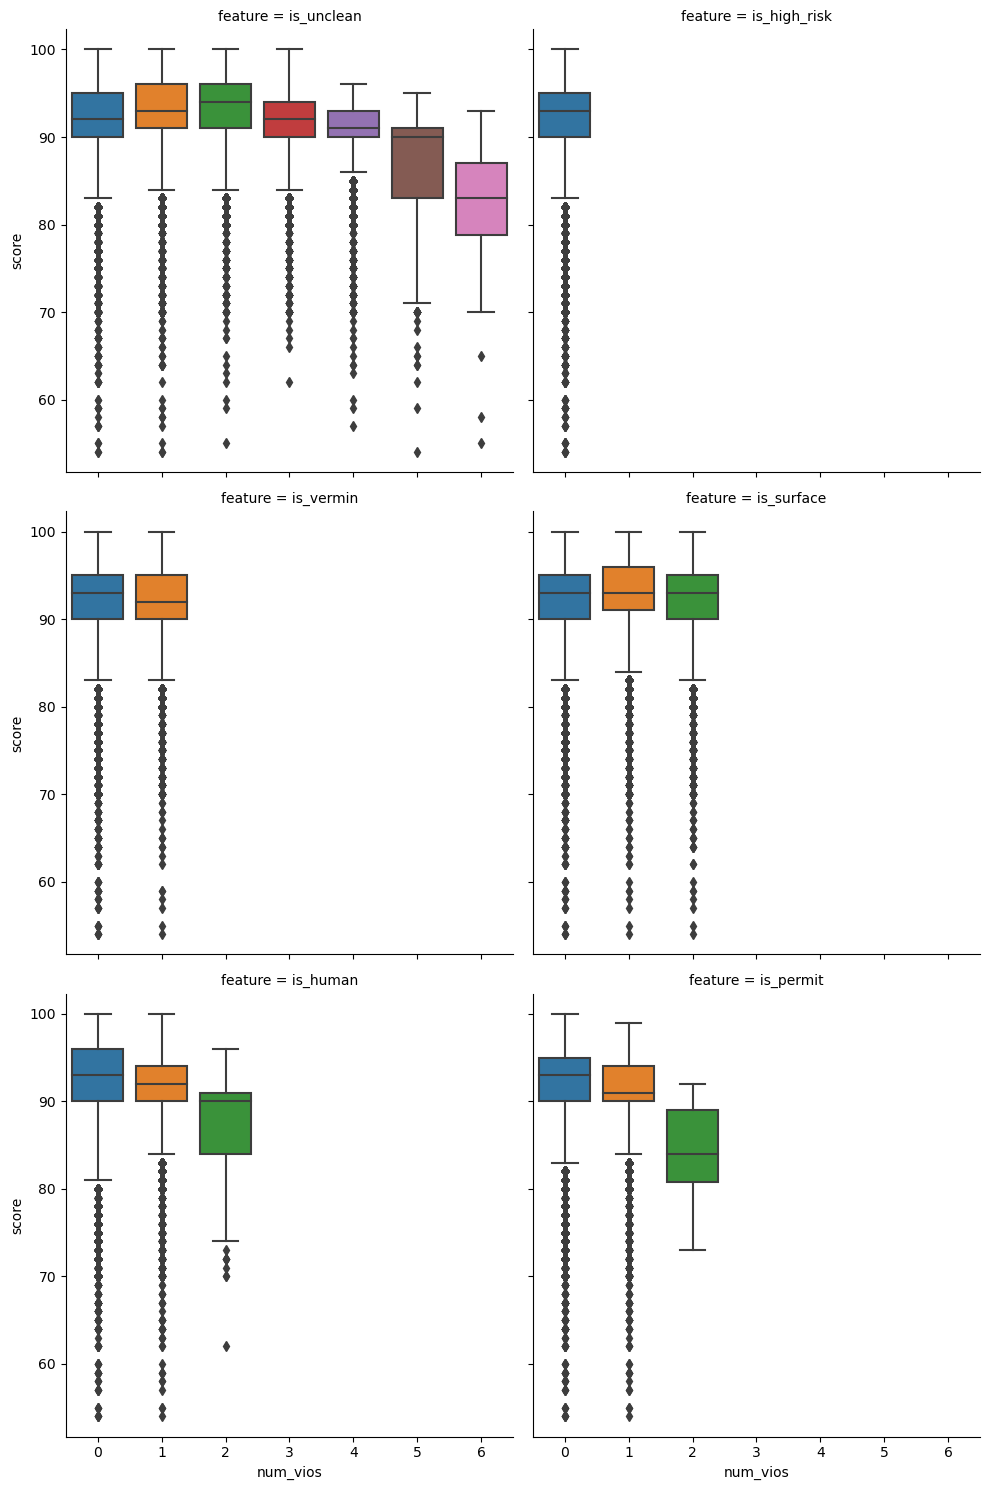

In [84]:
# you will learn this syntax next week. Focus on interpreting for now.
sns.catplot(x='num_vios', y='score',
               col='feature', col_wrap=2,
               kind='box',
               data=violation_type_and_scores);
